In [34]:
# Importons toutes les librairies dont nous aurons besoin
import gradio as gd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
# Lecture de notre dataset
df = pd.read_csv("/content/drive/MyDrive/Afriaisolution/Fashion_sales.csv",sep=',')
df.head()

,Order_ID,Customer_Name,Product_Category,Product_Name,Units_Sold,Unit_Price,Discount_%,Sales_Amount,Order_Date,City,Segment,Profit
0,1000,Brian Thompson,Jeans,Slim Fit Jeans,NaN,842.00,0.60,0.00,2025-02-27,Delhi,B2C,2137.45
1,1001,Shaun Ross,Jeans,Slim Fit Jeans,1.0,NaN,NaN,0.00,2025-07-15,Ahmedabad,NaN,1588.15
2,1002,Sarah Snyder,Jackets,Puffer Coat,1.0,637.82,NaN,0.00,02-01-2025,Mumbai,B2B,-158.03
3,1003,Jay Briggs,Shoes,Loafers,2.0,2962.27,NaN,0.00,18-06-2025,bengaluru,B2B,2296.50
4,1004,Maria Blake,Accessories,Belts,1.0,2881.07,0.27,2103.18,NaN,hyderbad,NaN,63.66


In [36]:
# la dimmension du dataset
df.shape

(2500, 12)

In [37]:
# Colonnes du DataFrame
print(df.columns.tolist())

['Order_ID', 'Customer_Name', 'Product_Category', 'Product_Name', 'Units_Sold', 'Unit_Price', 'Discount_%', 'Sales_Amount', 'Order_Date', 'City', 'Segment', 'Profit']


In [38]:
# Type des variables
df.dtypes

,0
Order_ID,int64
Customer_Name,object
Product_Category,object
Product_Name,object
Units_Sold,float64
Unit_Price,float64
Discount_%,float64
Sales_Amount,float64
Order_Date,object
City,object


In [39]:
# Statistiques de la variable cible Profit
df.Profit.describe()

,Profit
count,2500.000000
mean,981.569032
std,1159.159244
min,-992.610000
25%,-19.670000
50%,947.885000
75%,1993.515000
max,2997.110000


# Distribution de la variable cible Profit

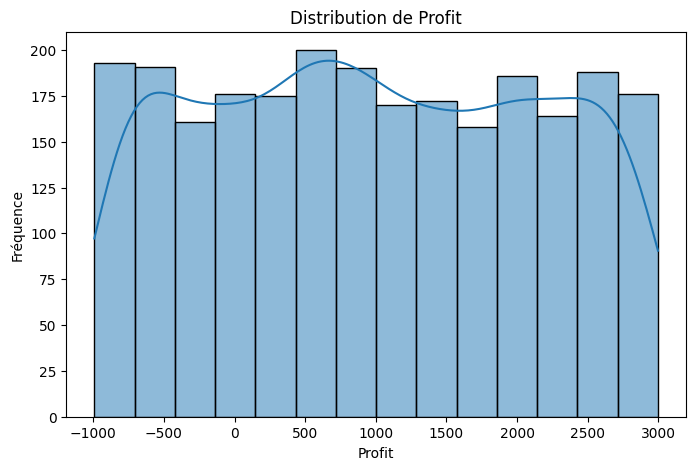

In [40]:
# Visualisation de la variable cible Profit
plt.figure(figsize=(8,5))
sns.histplot(df['Profit'], kde=True)

plt.title('Distribution de Profit')
plt.xlabel('Profit')
plt.ylabel('Fréquence')

plt.show()

# Interpretation

1. L’analyse exploratoire de la variable cible Profit révèle une distribution relativement étalée et quasi symétrique, avec des valeurs comprises entre -992 et 2997. La moyenne (981) est proche de la médiane (947), suggérant une absence de forte asymétrie.

2. L’histogramme met en évidence une dispersion importante des valeurs, confirmée par un écart-type élevé (1159), traduisant une forte variabilité des profits. La présence de valeurs négatives indique des situations de pertes, probablement dues à des retours ou à des ventes à faible marge.

3. Cette variabilité rend le problème de prédiction plus réaliste et justifie l’utilisation de modèles robustes capables de capturer des relations non linéaires.

# Visualisations

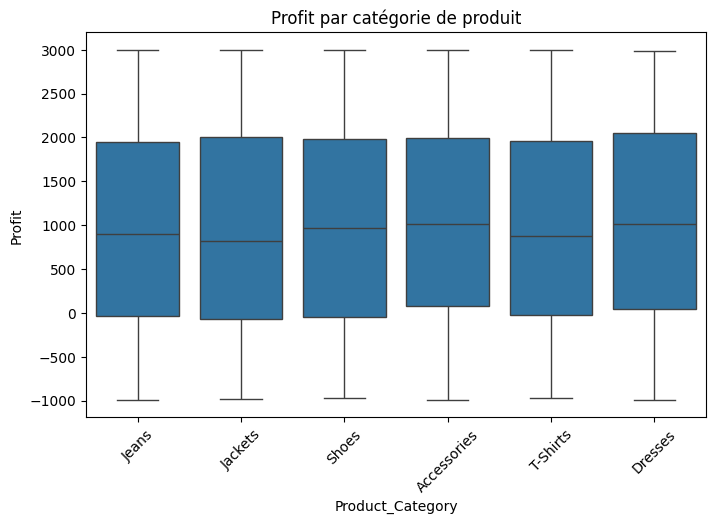

In [41]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Product_Category', y='Profit', data=df)

plt.title('Profit par catégorie de produit')
plt.xticks(rotation=45)

plt.show()

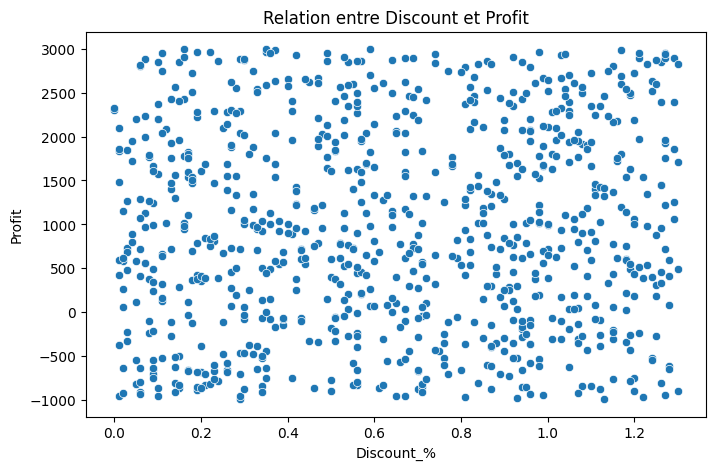

In [42]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Discount_%', y='Profit', data=df)

plt.title('Relation entre Discount et Profit')

plt.show()

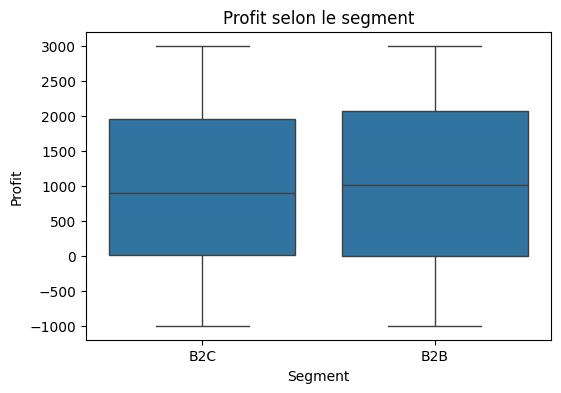

In [43]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Segment', y='Profit', data=df)

plt.title('Profit selon le segment')

plt.show()

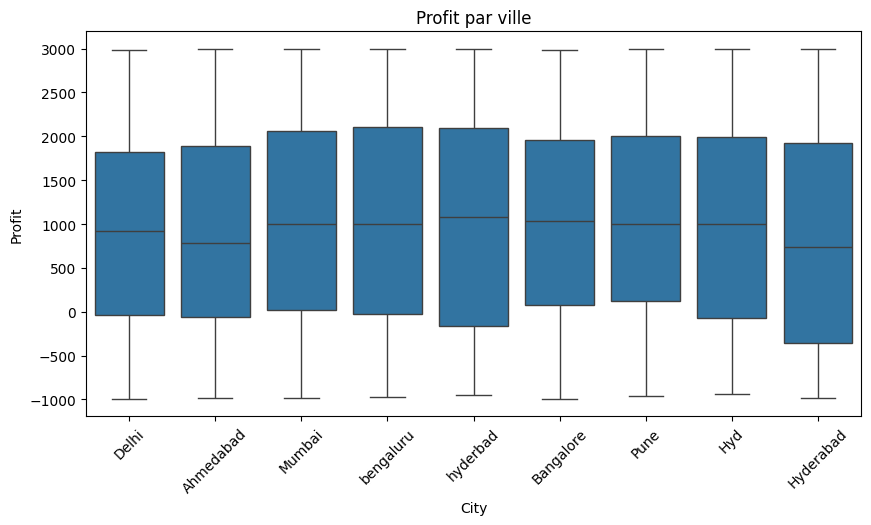

In [44]:
plt.figure(figsize=(10,5))
sns.boxplot(x='City', y='Profit', data=df)

plt.title('Profit par ville')
plt.xticks(rotation=45)

plt.show()

# Nettoyage & préparation

## Valeurs manquantes

In [45]:
# Vérifications de valeurs manquantes
df.isna().sum()

,0
Order_ID,0
Customer_Name,0
Product_Category,0
Product_Name,0
Units_Sold,1306
Unit_Price,1210
Discount_%,1651
Sales_Amount,0
Order_Date,606
City,0


# Impitations

1. L’analyse des valeurs manquantes a révélé une proportion importante de données absentes dans certaines variables, notamment Discount_%, Units_Sold et Unit_Price.

2. Afin de préserver un maximum d’observations, une stratégie d’imputation a été adoptée. Les variables numériques ont été imputées à l’aide de la médiane, robuste aux valeurs extrêmes. Les variables catégorielles, telles que Segment, ont été complétées par la modalité la plus fréquente.

3. Les variables non pertinentes, notamment les identifiants et les variables textuelles, ont été supprimées. La variable Order_Date a également été retirée en raison du nombre élevé de valeurs manquantes et de son impact limité dans cette analyse.

In [46]:
# 1. Imputation numérique
df['Units_Sold'].fillna(df['Units_Sold'].median(), inplace=True)
df['Unit_Price'].fillna(df['Unit_Price'].median(), inplace=True)
df['Discount_%'].fillna(df['Discount_%'].median(), inplace=True)

# 2. Imputation catégorielle
df['Segment'].fillna(df['Segment'].mode()[0], inplace=True)

# 3. Suppression colonnes inutiles
df = df.drop(columns=['Order_ID', 'Customer_Name', 'Product_Name', 'Order_Date'])


/tmp/ipykernel_3319/3442242866.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Units_Sold'].fillna(df['Units_Sold'].median(), inplace=True)
/tmp/ipykernel_3319/3442242866.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

### Verification

In [47]:
df.isna().sum()

,0
Product_Category,0
Units_Sold,0
Unit_Price,0
Discount_%,0
Sales_Amount,0
City,0
Segment,0
Profit,0


## Doublons

In [48]:
df.duplicated().sum()

np.int64(0)

### Aucun doublon identifié dans les données

In [49]:
df

,Product_Category,Units_Sold,Unit_Price,Discount_%,Sales_Amount,City,Segment,Profit
0,Jeans,2.0,842.000,0.60,0.00,Delhi,B2C,2137.45
1,Jeans,1.0,2685.985,0.65,0.00,Ahmedabad,B2B,1588.15
2,Jackets,1.0,637.820,0.65,0.00,Mumbai,B2B,-158.03
3,Shoes,2.0,2962.270,0.65,0.00,bengaluru,B2B,2296.50
4,Accessories,1.0,2881.070,0.27,2103.18,hyderbad,B2B,63.66
...,...,...,...,...,...,...,...,...
2495,T-Shirts,2.0,848.790,0.65,0.00,Mumbai,B2B,2259.00
2496,Shoes,4.0,2685.985,0.65,0.00,Hyderabad,B2B,2232.98
2497,Jackets,2.0,3389.240,1.06,0.00,Ahmedabad,B2C,1955.31
2498,Jeans,5.0,3844.190,0.65,0.00,Hyd,B2B,2967.00


# Variable Sales_Amount vue comme dérivée

1. Afin de vérifier la cohérence de la variable Sales_Amount, l’analyse a été restreinte aux observations non nulles (179 cas). Une comparaison avec une version recalculée à partir de Units_Sold, Unit_Price et Discount_% a été réalisée.

2. Les résultats montrent une forte concordance entre les deux variables, confirmant que Sales_Amount est une variable dérivée. Les écarts observés sont marginaux et peuvent être attribués à des effets d’arrondi ou à du bruit dans les données.

3. Par conséquent, cette variable a été supprimée afin d’éviter toute redondance et d’améliorer la robustesse du modèle.

In [50]:
df_non_zero = df[df['Sales_Amount'] != 0].copy()

In [51]:
df_non_zero['Sales_recomputed'] = (
    df_non_zero['Units_Sold'] *
    df_non_zero['Unit_Price'] *
    (1 - df_non_zero['Discount_%'])
)

In [52]:
(df_non_zero['Sales_Amount'] - df_non_zero['Sales_recomputed']).describe()

,0
count,179.000000
mean,-0.000145
std,0.002797
min,-0.005000
25%,-0.002400
50%,0.000200
75%,0.002000
max,0.004900


In [53]:
df_non_zero[['Sales_Amount', 'Sales_recomputed']].corr()

,Sales_Amount,Sales_recomputed
Sales_Amount,1.0,1.0
Sales_recomputed,1.0,1.0


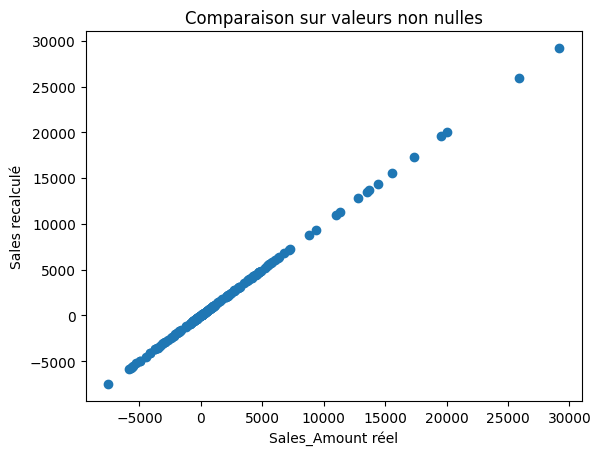

In [54]:
import matplotlib.pyplot as plt

plt.scatter(df_non_zero['Sales_Amount'], df_non_zero['Sales_recomputed'])
plt.xlabel("Sales_Amount réel")
plt.ylabel("Sales recalculé")
plt.title("Comparaison sur valeurs non nulles")
plt.show()

1. La variable Sales_Amount, identifiée comme dérivée des variables Units_Sold, Unit_Price et Discount_%, a été supprimée après vérification de sa redondance et de ses incohérences.

2. Une variable intermédiaire (Sales_recomputed) utilisée pour la validation a également été supprimée afin de ne conserver que les variables pertinentes pour la modélisation

In [55]:
df = df.drop(columns=['Sales_Amount', 'Sales_recomputed'], errors='ignore')

1. Une analyse de la variable Discount_% a révélé la présence de valeurs supérieures à 1, correspondant à des réductions supérieures à 100%, ce qui est incohérent d’un point de vue métier.

2. Ces observations ont été considérées comme des erreurs de saisie et ont été supprimées afin de garantir la qualité et la fiabilité des données utilisées pour la modélisation.

In [56]:
df = df[df['Discount_%'] <= 1]

In [57]:
df['Discount_%'].describe()

,Discount_%
count,2311.000000
mean,0.607815
std,0.174026
min,0.000000
25%,0.650000
50%,0.650000
75%,0.650000
max,1.000000


## Encodage des variables catégorielles

1. Les variables catégorielles (City, Segment, Product_Category) ont été encodées à l’aide de la méthode One-Hot Encoding.

2. Le Label Encoding n’a pas été retenu, car il introduit un ordre artificiel entre les catégories, ce qui peut biaiser les modèles de régression. Le One-Hot Encoding permet de représenter chaque catégorie de manière indépendante, garantissant ainsi une meilleure interprétation et performance du modèle.

In [58]:
df = pd.get_dummies(df, columns=['Segment', 'Product_Category', 'City'], drop_first=True)

# Normalisation & séparation

In [59]:
X = df.drop(columns=['Profit'])
y = df['Profit']

### Les données ont été divisées en un ensemble d’entraînement (80%) et un ensemble de test (20%) afin d’évaluer la capacité de généralisation du modèle sur des données non vues

In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

### Les variables numériques ont été standardisées à l’aide de StandardScaler afin d’assurer une échelle homogène entre les variables et d’améliorer les performances des modèles sensibles à la variance des données.

In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# MODELISATION

In [63]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# ------------------------
# 1. Modèles
# ------------------------
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42)
gbr = GradientBoostingRegressor(random_state=42)

# ------------------------
# 2. Entraînement
# ------------------------
lr.fit(X_train_scaled, y_train)
rf.fit(X_train_scaled, y_train)
gbr.fit(X_train_scaled, y_train)

# ------------------------
# 3. Prédictions
# ------------------------
y_pred_lr = lr.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test_scaled)
y_pred_gbr = gbr.predict(X_test_scaled)

# ------------------------
# 4. Évaluation
# ------------------------
def evaluate(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, r2

mse_lr, rmse_lr, r2_lr = evaluate(y_test, y_pred_lr)
mse_rf, rmse_rf, r2_rf = evaluate(y_test, y_pred_rf)
mse_gbr, rmse_gbr, r2_gbr = evaluate(y_test, y_pred_gbr)

# ------------------------
# 5. Résultats
# ------------------------
print("Linear Regression")
print("MSE:", mse_lr)
print("RMSE:", rmse_lr)
print("R²:", r2_lr)

print("\nRandom Forest")
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

print("\nGradient Boosting")
print("MSE:", mse_gbr)
print("RMSE:", rmse_gbr)
print("R²:", r2_gbr)

Linear Regression
MSE: 1333685.1218298955
RMSE: 1154.8528572203022
R²: -0.008168788940675409

Random Forest
MSE: 1591312.9408406361
RMSE: 1261.4725287697058
R²: -0.20291665111455792

Gradient Boosting
MSE: 1402015.0158495193
RMSE: 1184.0671500592857
R²: -0.059821210771467515


# Interprétation

1. Les performances des modèles entraînés montrent des valeurs de R² négatives, indiquant que les modèles ne parviennent pas à expliquer correctement la variabilité de la variable cible Profit.

2. La régression linéaire présente les meilleures performances relatives avec le RMSE le plus faible, bien que son pouvoir explicatif reste limité.

3. Ces résultats suggèrent que les variables explicatives disponibles ne capturent pas suffisamment les facteurs déterminants du profit. Cela peut être dû à l’absence de variables clés telles que les coûts ou les marges, ainsi qu’à la présence de bruit dans les données, notamment en raison de l’imputation de nombreuses valeurs manquantes.

In [64]:
import joblib

# Sauvegarder les 3 modèles
joblib.dump(lr, "linear_model.pkl")
joblib.dump(rf, "rf_model.pkl")
joblib.dump(gbr, "gbr_model.pkl")

# Sauvegarder les colonnes
joblib.dump(X.columns, "columns.pkl")

['columns.pkl']

# INTERFACE GRADIO

In [65]:
import gradio as gr
import pandas as pd
import joblib

# ==============================
# Charger les modèles
# ==============================
lr = joblib.load("linear_model.pkl")
rf = joblib.load("rf_model.pkl")
gbr = joblib.load("gbr_model.pkl")

expected_columns = joblib.load("columns.pkl")

# ==============================
# Définir le meilleur modèle
# ==============================
BEST_MODEL = "Linear Regression"  # basé sur tes résultats

# ==============================
# Fonction de prédiction
# ==============================
def predict_profit(units_sold, unit_price, discount, segment, category, city, model_choice):

    data = pd.DataFrame([{
        "Units_Sold": units_sold,
        "Unit_Price": unit_price,
        "Discount_%": discount,
        "Segment": segment,
        "Product_Category": category,
        "City": city
    }])

    # One-hot encoding
    data = pd.get_dummies(data)

    # Ajouter colonnes manquantes
    for col in expected_columns:
        if col not in data:
            data[col] = 0

    data = data[expected_columns]

    # Choix du modèle
    if model_choice == "Linear Regression":
        prediction = lr.predict(data)[0]
    elif model_choice == "Random Forest":
        prediction = rf.predict(data)[0]
    elif model_choice == "Gradient Boosting":
        prediction = gbr.predict(data)[0]
    else:
        return "Choix invalide"

    return f"💰 Profit estimé : {prediction:,.2f} USD"


# ==============================
# DESIGN PREMIUM
# ==============================
theme = gr.themes.Soft(
    primary_hue="purple",
    secondary_hue="blue",
    radius_size="lg"
)

with gr.Blocks(theme=theme) as app:

    gr.Markdown(
        f"""
        # 💰 AI Profit Prediction App
        ### 📊 Prédiction intelligente du profit

        ✅ **Meilleur modèle recommandé : {BEST_MODEL}**
        """
    )

    with gr.Row():
        with gr.Column():
            units_sold = gr.Slider(0, 1000, step=1, label="📦 Units Sold")
            unit_price = gr.Slider(1, 1000, step=1, label="💲 Unit Price")
            discount = gr.Slider(0, 1, step=0.01, label="🏷️ Discount (%)")

        with gr.Column():
            segment = gr.Dropdown(
                ["Consumer", "Corporate", "Home Office"],
                label="👤 Segment"
            )

            category = gr.Dropdown(
                ["Technology", "Furniture", "Office Supplies"],
                label="📂 Product Category"
            )

            city = gr.Dropdown(
                ["Dakar", "Thiès", "Saint-Louis", "Ziguinchor"],
                label="🌍 City"
            )

    model_choice = gr.Radio(
        ["Linear Regression", "Random Forest", "Gradient Boosting"],
        label="🤖 Choisir le modèle",
        value=BEST_MODEL
    )

    predict_btn = gr.Button("🚀 Lancer la prédiction", variant="primary")

    output = gr.Textbox(label="📈 Résultat")

    predict_btn.click(
        fn=predict_profit,
        inputs=[
            units_sold,
            unit_price,
            discount,
            segment,
            category,
            city,
            model_choice
        ],
        outputs=output
    )

    gr.Markdown(
        """
        ---
        ⚡ Application développée avec Gradio
        🎯 Objectif : Aide à la décision business
        """
    )

app.launch()

/tmp/ipykernel_3319/3697028908.py:65: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=theme) as app:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://70e81b7e5e73eab35e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
